In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

In [19]:
load_dotenv()
SERVER = os.environ.get("DB_SERVER")
DATABASE = os.environ.get("DB_NAME")
DRIVER = os.environ.get("DB_DRIVER")
PATH_STRING = os.environ.get("FILE_PATH")

QUERIES_FOLDER = Path(PATH_STRING) / "queries" 
SQL_FILE_PATH = QUERIES_FOLDER / "delivery_time.sql"

In [20]:
with open(SQL_FILE_PATH, 'r') as file: 
    sql_query = file.read()

engine = create_engine(f"mssql+pyodbc://{SERVER}/{DATABASE}?driver={DRIVER}")

df = pd.read_sql_query(sql_query, con=engine)


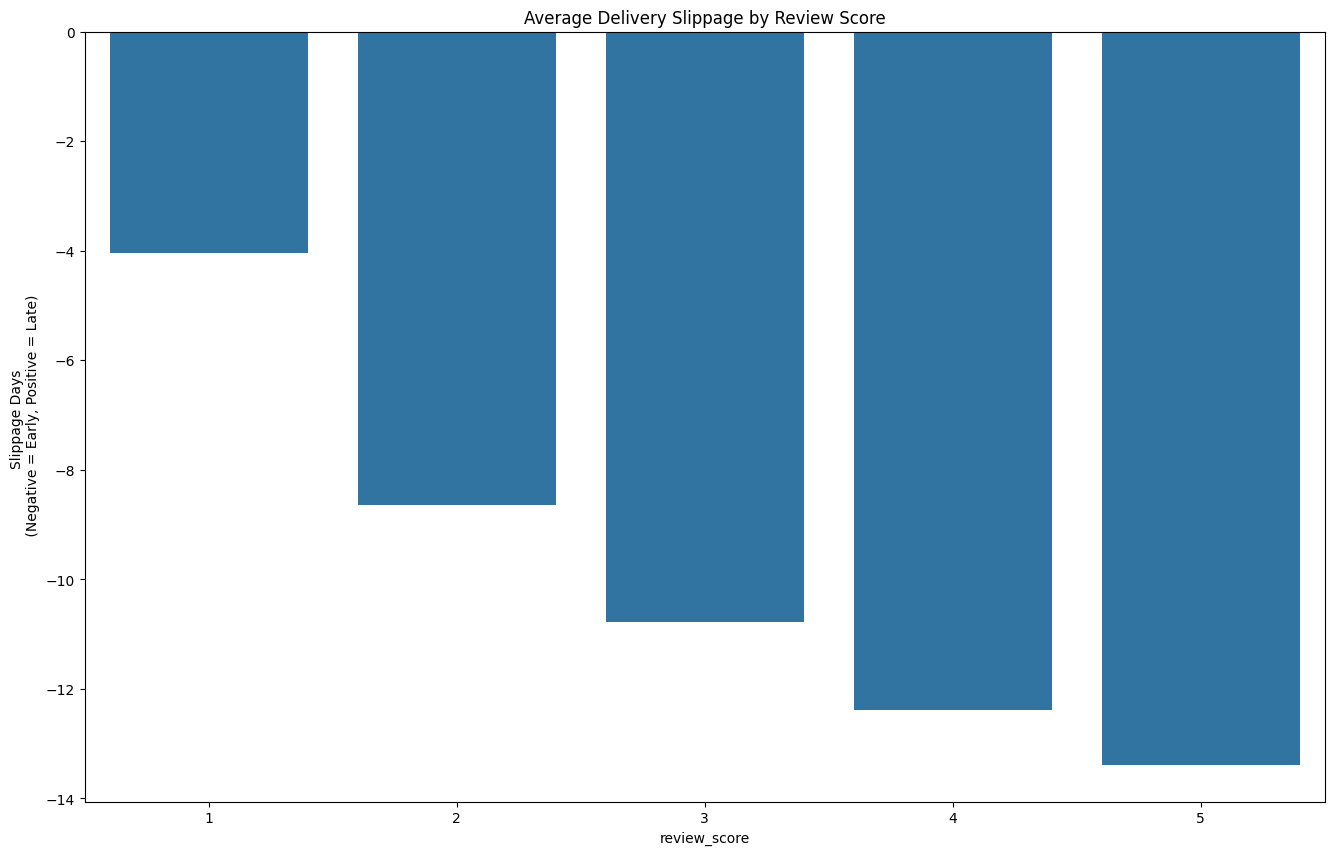

In [21]:
# Review Scores vs. Delivery Speed (scatter plot)
# convert dates columns to date time
columns_to_datetime = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
df[columns_to_datetime] = df[columns_to_datetime].apply(pd.to_datetime, errors = "coerce")

# get the duration of delivery in days
df["delivery_duration"]  = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["deliver_slippage_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

# make scatter plot
plt.figure(figsize=(16,10))
sns.barplot(df, x="review_score", y="deliver_slippage_days", errorbar=None)
plt.ylabel("Slippage Days \n (Negative = Early, Positive = Late)")
plt.title("Average Delivery Slippage by Review Score", fontsize=12)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

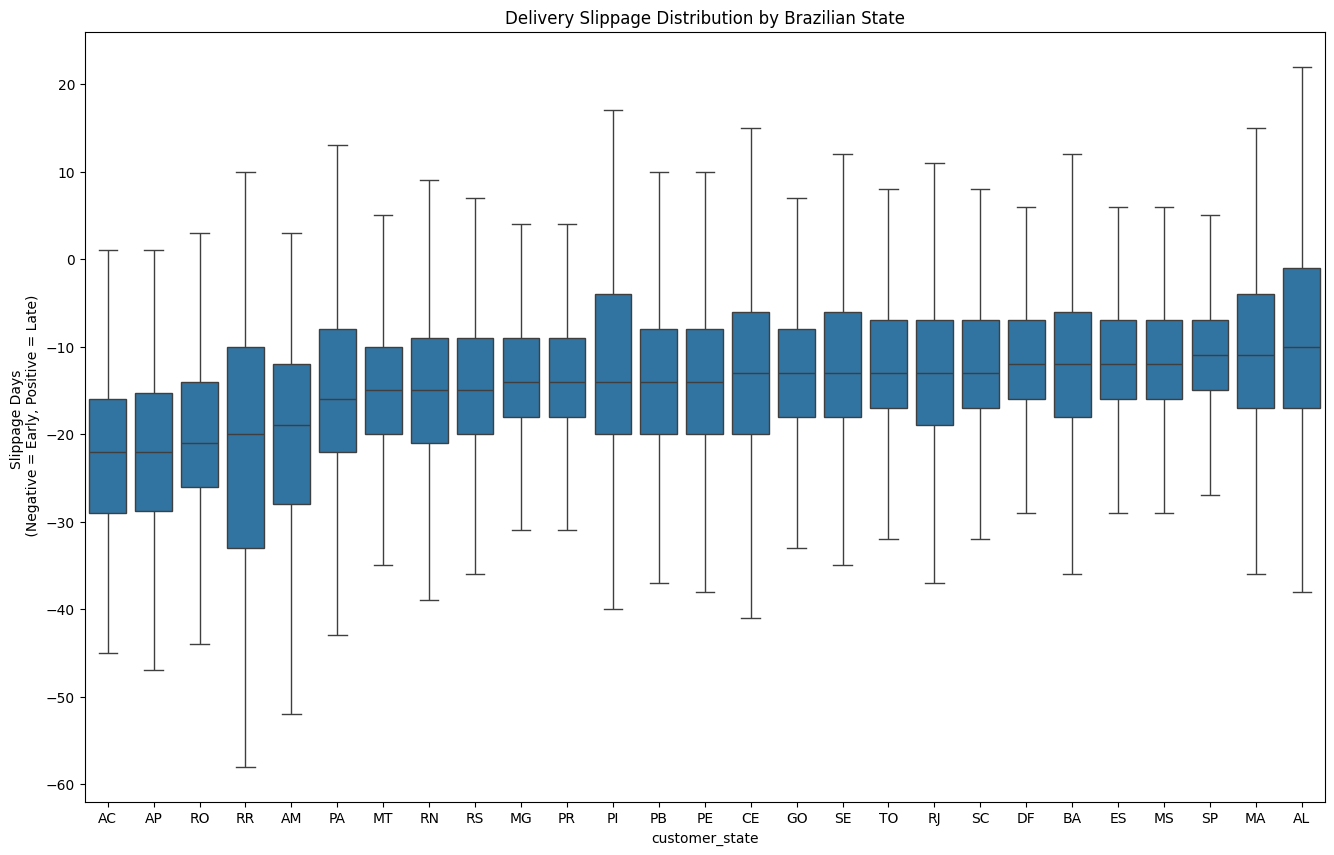

In [22]:
plt.close()

# make box plot showing delivery slippage for each region
plt.figure(figsize=(16,10))
state_order = df.groupby("customer_state")["deliver_slippage_days"].median().sort_values().index
sns.boxplot(data=df, x="customer_state", y="deliver_slippage_days", order=state_order, showfliers=False)
plt.ylabel("Slippage Days \n (Negative = Early, Positive = Late)")
plt.title("Delivery Slippage Distribution by Brazilian State", fontsize=12)
plt.show